# Interpretable Transformer Models (Transfer Learning)
## Lab: MobileViT vs ConViT vs ViT — Training, Attention Explanations, Robustness, Failure Analysis

### Learning Outcomes
By the end of this lab, you will be able to:
1. Fine-tune transformer-based vision models with **transfer learning**.
2. Compare **ViT**, **ConViT**, and **Swin** on the same dataset pipeline.
3. Capture and visualize **attention** (CLS → patch importance) using hooks.
4. Use **attention rollout** to build a simple, model-agnostic explanation map.
5. Evaluate **robustness** under noise, blur, occlusion, and color shift.
6. Perform **failure analysis** by inspecting misclassified examples.

# Imports, Reproducibility, Paths

In [1]:
import os
import sys
import random
import subprocess
import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_DIR = "/kaggle/input/pumpkin/Original/Original"
assert os.path.isdir(DATA_DIR), f"Dataset directory not found: {DATA_DIR}"
print("DATA_DIR:", DATA_DIR)
print("Subfolders:", os.listdir(DATA_DIR))

DEVICE: cuda
DATA_DIR: /kaggle/input/pumpkin/Original/Original
Subfolders: ['Powdery Mildew', 'Bacterial Leaf Spot', 'Healthy Leaf', 'Downy Mildew', 'Mosaic Disease']


## Model Zoo Access via `timm`

We use `timm` to load pretrained:
- MobileViT
- ConViT
- ViT

If `timm` is already installed, this cell will still work.

In [2]:
def ensure_timm():
    try:
        import timm
        return timm
    except Exception:
        print("Installing timm...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
        import timm
        return timm

timm = ensure_timm()
print("timm version:", timm.__version__)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

timm version: 1.0.20


## Data Pipeline (ImageFolder → Split → Train/Val Loaders)

We keep preprocessing stable across models:
- Resize to 224×224
- Light augmentations for training
- Standard ImageNet normalization (common for pretrained models)

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

base_ds = datasets.ImageFolder(DATA_DIR)
class_names = base_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Num classes:", num_classes)
print("Total images:", len(base_ds))

val_ratio = 0.2
val_len = int(len(base_ds) * val_ratio)
train_len = len(base_ds) - val_len

g = torch.Generator().manual_seed(SEED)
train_base, val_base = random_split(base_ds, [train_len, val_len], generator=g)

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

train_ds = TransformSubset(train_base, train_tfms)
val_ds   = TransformSubset(val_base, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train size:", len(train_ds), "Val size:", len(val_ds))

Classes: ['Bacterial Leaf Spot', 'Downy Mildew', 'Healthy Leaf', 'Mosaic Disease', 'Powdery Mildew']
Num classes: 5
Total images: 2000
Train size: 1600 Val size: 400


### Batch Visualization (Sanity Check)

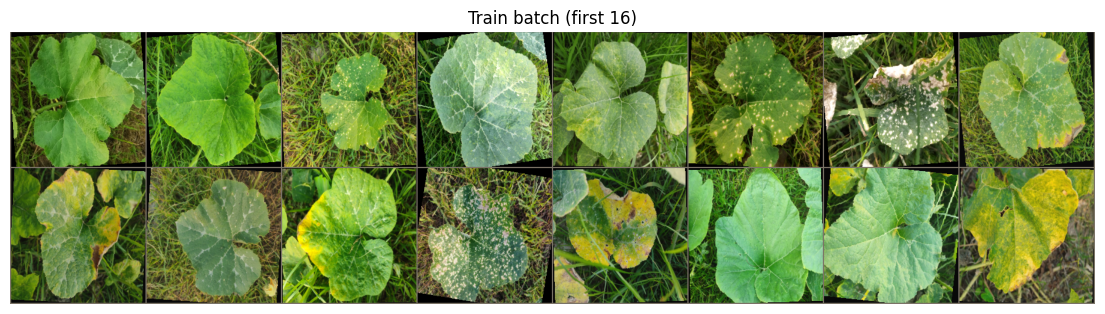

Labels: ['Healthy Leaf', 'Healthy Leaf', 'Powdery Mildew', 'Bacterial Leaf Spot', 'Powdery Mildew', 'Powdery Mildew', 'Powdery Mildew', 'Downy Mildew', 'Downy Mildew', 'Bacterial Leaf Spot', 'Downy Mildew', 'Powdery Mildew', 'Downy Mildew', 'Healthy Leaf', 'Healthy Leaf', 'Mosaic Disease']


In [4]:
MEAN = np.array(IMAGENET_MEAN, dtype=np.float32)
STD  = np.array(IMAGENET_STD, dtype=np.float32)

def denorm_grid(t_grid):
    # t_grid: (3,H,W) torch
    x = t_grid.detach().cpu().numpy().transpose(1,2,0)
    x = (x * STD) + MEAN
    return np.clip(x, 0, 1)

xb, yb = next(iter(train_loader))
grid = make_grid(xb[:16], nrow=8)

plt.figure(figsize=(14,6))
plt.imshow(denorm_grid(grid))
plt.axis("off")
plt.title("Train batch (first 16)")
plt.show()

print("Labels:", [class_names[i] for i in yb[:16].tolist()])

## Training Utilities (with Mixed Precision AMP)

AMP speeds up training on GPU and reduces memory usage.
- On CUDA: uses autocast + GradScaler
- On CPU: automatically falls back to FP32

In [5]:
from tqdm import tqdm

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def _amp_enabled(device: str) -> bool:
    return (device == "cuda") and torch.cuda.is_available()

def train_one_epoch(model, loader, optim, criterion, scaler=None):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    use_amp = (scaler is not None) and _amp_enabled(DEVICE)

    for x, y in tqdm(loader, desc="train", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optim.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    use_amp = _amp_enabled(DEVICE)

    for x, y in tqdm(loader, desc="eval", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)

        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
        else:
            logits = model(x)
            loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

def fit(model, train_loader, val_loader, lr=1e-3, epochs=3, weight_decay=1e-4, use_mixed_precision=True):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    optim = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay
    )

    scaler = None
    if use_mixed_precision and _amp_enabled(DEVICE):
        scaler = torch.cuda.amp.GradScaler()
        print("AMP: Enabled (CUDA + GradScaler)")
    else:
        print("AMP: Disabled (FP32)")

    hist = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optim, criterion, scaler=scaler)
        va_loss, va_acc = eval_one_epoch(model, val_loader, criterion)
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)
        print(f"Epoch {ep}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    return model, hist

def plot_history(hist, title="Training curves"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist["train_loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title("Loss"); plt.legend(); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(hist["train_acc"], label="train")
    plt.plot(hist["val_acc"], label="val")
    plt.title("Accuracy"); plt.legend(); plt.grid(True)

    plt.suptitle(title)
    plt.show()

# Model Selection (Transfer Learning)

We will compare three pretrained transformer-based model families for image classification:

- **ViT (Vision Transformer)**:  
  A standard transformer architecture that operates on fixed-size image patches and models global relationships via self-attention. ViT serves as a strong baseline for studying pure token-based vision transformers without explicit convolutional inductive biases.

- **ConViT (Convolutional Vision Transformer)**:  
  A hybrid transformer that extends ViT by introducing soft convolutional inductive biases into the self-attention mechanism. ConViT encourages locality in early layers while still allowing global attention, often improving performance and data efficiency on vision tasks with limited training data.

- **Swin Transformer**:  
  A hierarchical vision transformer that computes self-attention within shifted local windows. Swin introduces multi-scale feature representations similar to CNNs while maintaining the modeling flexibility of transformers, making it highly effective for both classification and dense vision tasks.

For all models, we adopt a transfer learning strategy by initializing the network with ImageNet-pretrained weights and replacing the final classification head to match the number of target classes. Models are instantiated using:

```python
timm.create_model(model_name, pretrained=True, num_classes=num_classes)


In [6]:
import timm

# -------------------------------------------------
# Utility: try to create a timm model safely
# -------------------------------------------------
def try_create(model_name):
    try:
        _ = timm.create_model(model_name, pretrained=True)
        print(f"[OK]   {model_name}")
        return model_name
    except Exception as e:
        print(f"[FAIL] {model_name}")
        return None


def pick_first_working(candidates):
    for name in candidates:
        if try_create(name) is not None:
            return name
    return None


# -------------------------------------------------
# Model candidates (ordered by preference)
# -------------------------------------------------
VIT_CANDIDATES = [
    "vit_base_patch16_224",
    "vit_small_patch16_224",
    "vit_tiny_patch16_224",
]

CONVIT_CANDIDATES = [
    "convit_small",
    "convit_tiny",
]

SWIN_CANDIDATES = [
    "swin_base_patch4_window7_224",
    "swin_small_patch4_window7_224",
    "swin_tiny_patch4_window7_224",
]


# -------------------------------------------------
# Pick first available model from each family
# -------------------------------------------------
MODEL_VIT    = pick_first_working(VIT_CANDIDATES)
MODEL_CONVIT = pick_first_working(CONVIT_CANDIDATES)
MODEL_SWIN   = pick_first_working(SWIN_CANDIDATES)


# -------------------------------------------------
# Summary
# -------------------------------------------------
print("\nSelected Models:")
print("ViT    :", MODEL_VIT)
print("ConViT :", MODEL_CONVIT)
print("Swin   :", MODEL_SWIN)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[OK]   vit_base_patch16_224


model.safetensors:   0%|          | 0.00/111M [00:00<?, ?B/s]

[OK]   convit_small


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

[OK]   swin_base_patch4_window7_224

Selected Models:
ViT    : vit_base_patch16_224
ConViT : convit_small
Swin   : swin_base_patch4_window7_224


## Transfer learning helpers (freeze head / unfreeze last blocks)

In [7]:
import torch.nn as nn
import timm

# -----------------------------
# Build model
# -----------------------------
def build_timm_model(model_name: str, num_classes: int, pretrained=True):
    return timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)

# -----------------------------
# Freeze / Unfreeze helpers
# -----------------------------
def freeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_module(module: nn.Module):
    for p in module.parameters():
        p.requires_grad = True

def _get_classifier_module(model: nn.Module):
    """
    Robustly returns the classifier/head module for timm models.
    """
    head = None

    # timm standard
    if hasattr(model, "get_classifier"):
        try:
            head = model.get_classifier()
        except Exception:
            head = None

    # if get_classifier returns a string or None in rare cases, fall back
    if not isinstance(head, nn.Module):
        head = None

    # common fallbacks
    if head is None:
        for attr in ["head", "fc", "classifier"]:
            if hasattr(model, attr) and isinstance(getattr(model, attr), nn.Module):
                head = getattr(model, attr)
                break

    return head

def freeze_backbone_keep_head_trainable(model: nn.Module, unfreeze_norm: bool = False):
    """
    Freezes all parameters, then unfreezes the classification head.
    Optionally unfreezes all normalization layers (LayerNorm/BatchNorm/etc.)
    which can help transfer learning stability.
    """
    freeze_all(model)

    head = _get_classifier_module(model)
    if head is not None:
        unfreeze_module(head)
    else:
        # Hard fallback: if head cannot be identified, keep everything trainable
        for p in model.parameters():
            p.requires_grad = True
        return model

    if unfreeze_norm:
        for m in model.modules():
            if isinstance(m, (nn.LayerNorm, nn.BatchNorm1d, nn.BatchNorm2d, nn.GroupNorm, nn.InstanceNorm2d)):
                unfreeze_module(m)

    return model

def try_unfreeze_last_blocks(model: nn.Module, n_blocks: int = 2, unfreeze_norm: bool = True):
    """
    Partial fine-tuning:
    - Always keeps head trainable
    - Unfreezes the last n transformer blocks/stages depending on architecture

    Supported:
    - ViT / ConViT: model.blocks (ModuleList)
    - Swin: model.layers (ModuleList of stages)
    """
    freeze_backbone_keep_head_trainable(model, unfreeze_norm=unfreeze_norm)

    # ViT / ConViT style
    if hasattr(model, "blocks") and isinstance(model.blocks, nn.ModuleList):
        blocks = list(model.blocks)
        for b in blocks[-n_blocks:]:
            unfreeze_module(b)
        return model

    # Swin style (hierarchical stages)
    if hasattr(model, "layers") and isinstance(model.layers, nn.ModuleList):
        layers = list(model.layers)
        for stage in layers[-n_blocks:]:
            unfreeze_module(stage)
        return model

    # If neither is present, do nothing beyond head (+ optional norm)
    return model


# Train all models (Frozen + Partial fine-tuning)

---

## 1. Frozen Fine-Tuning (Feature Extractor Mode)

**Definition**
All pretrained backbone layers are frozen. Only the newly added task-specific head (e.g., classifier, regressor) is trained.

**When to use**

* **Very small labeled dataset** (e.g., hundreds of samples).
* **High similarity** between the pretraining domain and your target domain.
* **Strict compute or time constraints**.
* **Baseline or rapid prototyping** is required.

**Reasons**

* Prevents overfitting by reducing trainable parameters.
* Leverages robust, general features learned during pretraining.
* Fast training; low memory footprint.

**Pros**

* Minimal risk of catastrophic forgetting.
* Stable convergence.
* Lowest computational cost.

**Cons**

* Limited adaptability to domain shift.
* Performance may plateau if task requires domain-specific features.

---

## 2. Partial Fine-Tuning (Selective Unfreezing)

**Definition**
Freeze early (general) layers; unfreeze and train later (task-specific) layers, along with the head.

**When to use**

* **Moderate dataset size** (thousands to tens of thousands).
* **Partial domain mismatch** (e.g., medical images vs. natural images).
* **Need higher accuracy** than frozen training can deliver.
* **Sufficient compute** to train a subset of the backbone.

**Reasons**

* Early layers capture generic primitives (edges, textures); later layers encode semantics.
* Unfreezing higher layers allows adaptation without destabilizing low-level features.
* Balances bias–variance and compute–performance trade-offs.

**Pros**

* Better task adaptation than frozen mode.
* Lower overfitting risk than full fine-tuning.
* Often the best practical default.

**Cons**

* Requires tuning (which layers to unfreeze, learning rates).
* More compute than frozen mode.

---

## 3. Practical Decision Table

| Scenario                               | Recommended Strategy | Rationale                               |
| -------------------------------------- | -------------------- | --------------------------------------- |
| Very small dataset, same domain        | **Frozen**           | Avoid overfitting; fast baseline        |
| Moderate dataset, some domain shift    | **Partial**          | Adapt semantics while keeping stability |
| Large dataset, strong domain shift     | **Full fine-tuning** | Learn domain-specific representations   |
| Limited GPU / tight deadline           | **Frozen**           | Minimal cost                            |
| Accuracy critical, resources available | **Partial**          | Best cost–performance balance           |

---

## 4. Training Tips (Best Practices)

* **Layer-wise learning rates**: smaller LR for pretrained layers; larger LR for the head.
* **Gradual unfreezing**: start frozen → unfreeze top blocks progressively.
* **Regularization**: weight decay, data augmentation, early stopping.
* **Monitoring**: watch validation loss for overfitting when unfreezing layers.

---

## 5. Bottom Line

* Choose **Frozen fine-tuning** for **data scarcity, speed, and stability**.
* Choose **Partial fine-tuning** for **better adaptation with manageable risk and cost**.
* If data and compute are abundant and domains differ substantially, consider **full fine-tuning**.



In [8]:
# ---------------------------------------------------------
# Training configuration (adjust to your compute budget)
# ---------------------------------------------------------
EPOCHS_FROZEN  = 5
EPOCHS_PARTIAL = 5

trained = {}

# ---------------------------------------------------------
# Model registry (architecture-aware)
# ---------------------------------------------------------
MODEL_REGISTRY = {
    "vit": {
        "name": MODEL_VIT,
        "partial_blocks": 2,
        "lr_frozen": 1e-3,
        "lr_partial": 3e-4,
    },
    "convit": {
        "name": MODEL_CONVIT,
        "partial_blocks": 2,
        "lr_frozen": 1e-3,
        "lr_partial": 3e-4,
    },
    "swin": {
        "name": MODEL_SWIN,   # must be defined earlier (e.g., swin_tiny_patch4_window7_224)
        "partial_blocks": 1,  # Swin unfreezes last *stage*, not block
        "lr_frozen": 1e-3,
        "lr_partial": 2e-4,   # slightly lower LR is usually safer for Swin
    }
}



Training VIT | vit_base_patch16_224


/tmp/ipykernel_24/3035749162.py:74: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


VIT trainable params (frozen): 2
AMP: Enabled (CUDA + GradScaler)


train:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_24/3035749162.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
eval:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_24/3035749162.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 | train loss 0.9284 acc 0.6556 | val loss 0.6360 acc 0.7650


Epoch 2/5 | train loss 0.5196 acc 0.8213 | val loss 0.5359 acc 0.7950


Epoch 3/5 | train loss 0.4662 acc 0.8425 | val loss 0.5079 acc 0.8200


Epoch 4/5 | train loss 0.4390 acc 0.8500 | val loss 0.4989 acc 0.8250


Epoch 5/5 | train loss 0.4060 acc 0.8650 | val loss 0.4540 acc 0.8350


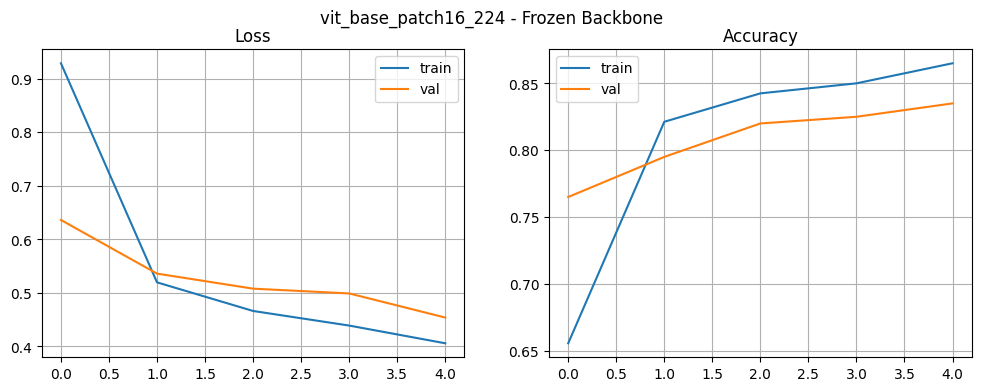

VIT trainable params (partial): 52
AMP: Enabled (CUDA + GradScaler)


Epoch 1/5 | train loss 1.1663 acc 0.5563 | val loss 0.8138 acc 0.7225


Epoch 2/5 | train loss 0.6339 acc 0.7869 | val loss 0.5743 acc 0.7800


Epoch 3/5 | train loss 0.5038 acc 0.8287 | val loss 0.5173 acc 0.8025


Epoch 4/5 | train loss 0.4587 acc 0.8356 | val loss 0.4769 acc 0.8200


Epoch 5/5 | train loss 0.4219 acc 0.8500 | val loss 0.4499 acc 0.8225


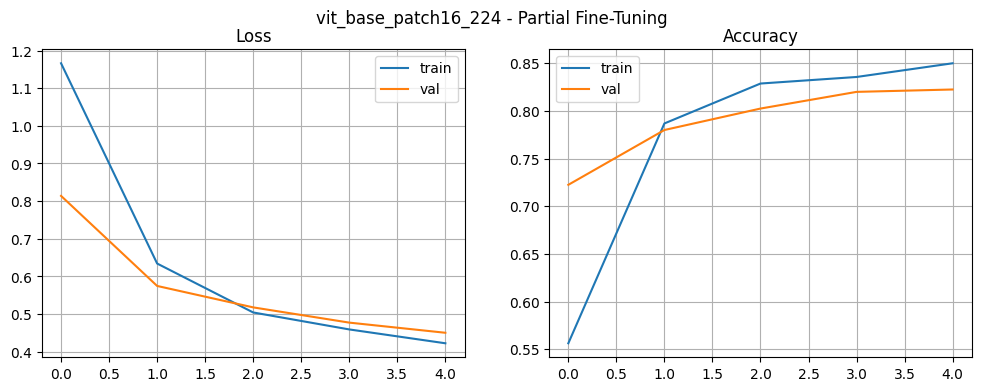


Training CONVIT | convit_small
CONVIT trainable params (frozen): 2
AMP: Enabled (CUDA + GradScaler)


Epoch 1/5 | train loss 1.1418 acc 0.5769 | val loss 0.9505 acc 0.6625


Epoch 2/5 | train loss 0.7945 acc 0.7275 | val loss 0.7988 acc 0.7425


Epoch 3/5 | train loss 0.6877 acc 0.7631 | val loss 0.7126 acc 0.7525


Epoch 4/5 | train loss 0.6227 acc 0.7963 | val loss 0.6707 acc 0.7775


Epoch 5/5 | train loss 0.5882 acc 0.8019 | val loss 0.6448 acc 0.7775


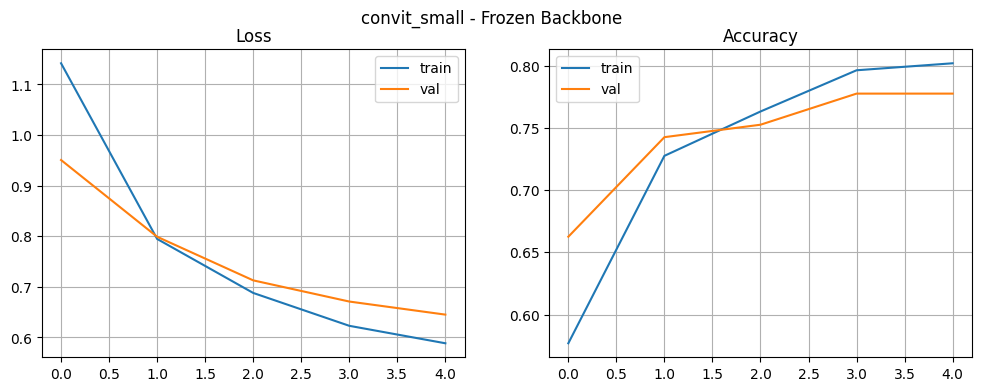

CONVIT trainable params (partial): 66
AMP: Enabled (CUDA + GradScaler)


Epoch 1/5 | train loss 0.7554 acc 0.7106 | val loss 0.5838 acc 0.7825


Epoch 2/5 | train loss 0.4509 acc 0.8313 | val loss 0.4499 acc 0.8550


Epoch 3/5 | train loss 0.3405 acc 0.8731 | val loss 0.4360 acc 0.8625


Epoch 4/5 | train loss 0.2672 acc 0.9031 | val loss 0.4594 acc 0.8400


Epoch 5/5 | train loss 0.2511 acc 0.9006 | val loss 0.5481 acc 0.8300


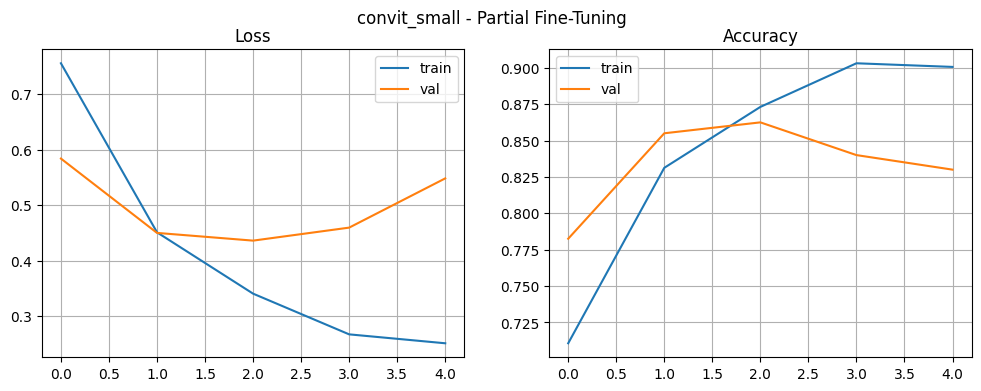


Training SWIN | swin_base_patch4_window7_224
SWIN trainable params (frozen): 2
AMP: Enabled (CUDA + GradScaler)


Epoch 1/5 | train loss 0.8991 acc 0.7031 | val loss 0.5794 acc 0.8325


Epoch 2/5 | train loss 0.5319 acc 0.8281 | val loss 0.5203 acc 0.8200


Epoch 3/5 | train loss 0.4762 acc 0.8387 | val loss 0.4851 acc 0.8550


Epoch 4/5 | train loss 0.4483 acc 0.8425 | val loss 0.4780 acc 0.8375


Epoch 5/5 | train loss 0.4420 acc 0.8531 | val loss 0.4579 acc 0.8425


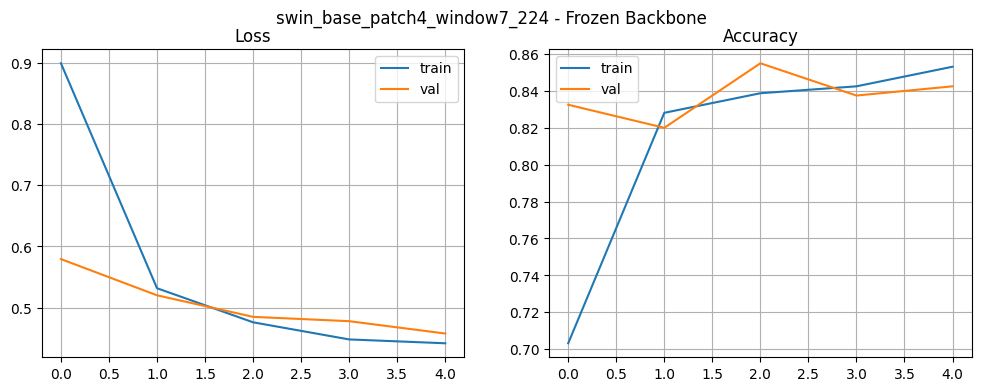

SWIN trainable params (partial): 108
AMP: Enabled (CUDA + GradScaler)


Epoch 1/5 | train loss 1.2798 acc 0.5681 | val loss 0.9357 acc 0.7475


Epoch 2/5 | train loss 0.7223 acc 0.7906 | val loss 0.5882 acc 0.8200


Epoch 3/5 | train loss 0.5466 acc 0.8175 | val loss 0.4904 acc 0.8350


Epoch 4/5 | train loss 0.4754 acc 0.8450 | val loss 0.4545 acc 0.8425


Epoch 5/5 | train loss 0.4477 acc 0.8531 | val loss 0.4501 acc 0.8375


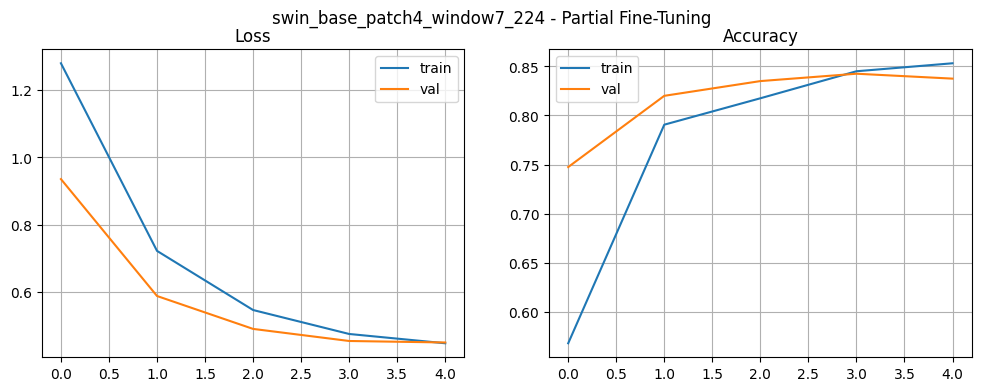

In [9]:
for model_key, cfg in MODEL_REGISTRY.items():

    model_name = cfg["name"]
    if model_name is None:
        print(f"Skipping {model_key}: model not available")
        continue

    print("\n" + "=" * 70)
    print(f"Training {model_key.upper()} | {model_name}")
    print("=" * 70)

    # -------------------------------------------------
    # Frozen backbone (head-only training)
    # -------------------------------------------------
    model_frozen = build_timm_model(model_name, num_classes).to(DEVICE)
    model_frozen = freeze_backbone_keep_head_trainable(
        model_frozen,
        unfreeze_norm=False
    )

    trainable_frozen = sum(p.requires_grad for p in model_frozen.parameters())
    print(f"{model_key.upper()} trainable params (frozen):", trainable_frozen)

    model_frozen, hist_frozen = fit(
        model_frozen,
        train_loader,
        val_loader,
        lr=cfg["lr_frozen"],
        epochs=EPOCHS_FROZEN
    )

    plot_history(hist_frozen, f"{model_name} - Frozen Backbone")
    trained[f"{model_key}_frozen"] = model_frozen

    # -------------------------------------------------
    # Partial fine-tuning (last blocks / stages)
    # -------------------------------------------------
    model_partial = build_timm_model(model_name, num_classes).to(DEVICE)
    model_partial = try_unfreeze_last_blocks(
        model_partial,
        n_blocks=cfg["partial_blocks"],
        unfreeze_norm=True
    )

    trainable_partial = sum(p.requires_grad for p in model_partial.parameters())
    print(f"{model_key.upper()} trainable params (partial):", trainable_partial)

    model_partial, hist_partial = fit(
        model_partial,
        train_loader,
        val_loader,
        lr=cfg["lr_partial"],
        epochs=EPOCHS_PARTIAL
    )

    plot_history(hist_partial, f"{model_name} - Partial Fine-Tuning")
    trained[f"{model_key}_partial"] = model_partial


# Evaluation utilities (classification report + confusion matrix)

In [10]:
# ---------------------------------------------------------
# Evaluation registry (matches trained dict keys)
# ---------------------------------------------------------
EVAL_MODELS = {
    "ViT (Frozen)":        "vit_frozen",
    "ViT (Partial)":       "vit_partial",
    "ConViT (Frozen)":     "convit_frozen",
    "ConViT (Partial)":    "convit_partial",
    "Swin (Frozen)":       "swin_frozen",
    "Swin (Partial)":      "swin_partial",
}


In [11]:
# Evaluation utilities (classification report + confusion matrix)
@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    all_y, all_p = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        p = logits.argmax(dim=1).detach().cpu().numpy()
        all_p.append(p)
        all_y.append(y.detach().cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    return y_true, y_pred

def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def precision_recall_f1_from_cm(cm):
    eps = 1e-12
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0).astype(np.float64) - tp
    fn = cm.sum(axis=1).astype(np.float64) - tp
    support = cm.sum(axis=1).astype(np.float64)

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)

    accuracy = tp.sum() / (cm.sum() + eps)

    macro_p = precision.mean()
    macro_r = recall.mean()
    macro_f = f1.mean()

    weights = support / (support.sum() + eps)
    weighted_p = (precision * weights).sum()
    weighted_r = (recall * weights).sum()
    weighted_f = (f1 * weights).sum()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "macro": (macro_p, macro_r, macro_f),
        "weighted": (weighted_p, weighted_r, weighted_f),
    }

def print_classification_report(metrics, class_names, digits=3):
    p = metrics["precision"]
    r = metrics["recall"]
    f = metrics["f1"]
    s = metrics["support"]

    print("Classification Report")
    print("-" * 72)
    print(f"{'Class':28s} {'Prec':>8s} {'Rec':>8s} {'F1':>8s} {'Support':>10s}")
    print("-" * 72)
    for i, name in enumerate(class_names):
        print(f"{name[:28]:28s} {p[i]:8.{digits}f} {r[i]:8.{digits}f} {f[i]:8.{digits}f} {int(s[i]):10d}")
    print("-" * 72)
    acc = metrics["accuracy"]
    mp, mr, mf = metrics["macro"]
    wp, wr, wf = metrics["weighted"]
    print(f"{'Accuracy':28s} {acc:8.{digits}f}")
    print(f"{'Macro avg':28s} {mp:8.{digits}f} {mr:8.{digits}f} {mf:8.{digits}f} {int(s.sum()):10d}")
    print(f"{'Weighted avg':28s} {wp:8.{digits}f} {wr:8.{digits}f} {wf:8.{digits}f} {int(s.sum()):10d}")
    print("-" * 72)

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False, figsize=(10,8)):
    if normalize:
        cm_disp = cm.astype(np.float64)
        row_sums = cm_disp.sum(axis=1, keepdims=True) + 1e-12
        cm_disp = cm_disp / row_sums
    else:
        cm_disp = cm

    plt.figure(figsize=figsize)
    plt.imshow(cm_disp)
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    n = len(class_names)
    ticks = np.arange(n)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    for i in range(n):
        for j in range(n):
            text = f"{cm_disp[i, j]:.2f}" if normalize else str(cm_disp[i, j])
            plt.text(j, i, text, ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, model_name, val_loader, class_names, device):
    print(f"\n==============================")
    print(f"Evaluating: {model_name}")
    print(f"==============================")
    y_true, y_pred = collect_preds(model, val_loader, device)
    cm = confusion_matrix_np(y_true, y_pred, num_classes=len(class_names))
    metrics = precision_recall_f1_from_cm(cm)
    print_classification_report(metrics, class_names, digits=3)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} - Confusion Matrix", normalize=False, figsize=(10,8))
    plot_confusion_matrix(cm, class_names, title=f"{model_name} - Confusion Matrix", normalize=True, figsize=(10,8))
    return metrics, cm


Evaluating: ViT (Frozen)
Classification Report
------------------------------------------------------------------------
Class                            Prec      Rec       F1    Support
------------------------------------------------------------------------
Bacterial Leaf Spot             0.698    0.779    0.736         77
Downy Mildew                    0.862    0.880    0.871         92
Healthy Leaf                    0.831    0.873    0.852         79
Mosaic Disease                  0.952    0.952    0.952         83
Powdery Mildew                  0.833    0.652    0.732         69
------------------------------------------------------------------------
Accuracy                        0.835
Macro avg                       0.835    0.827    0.829        400
Weighted avg                    0.838    0.835    0.834        400
------------------------------------------------------------------------


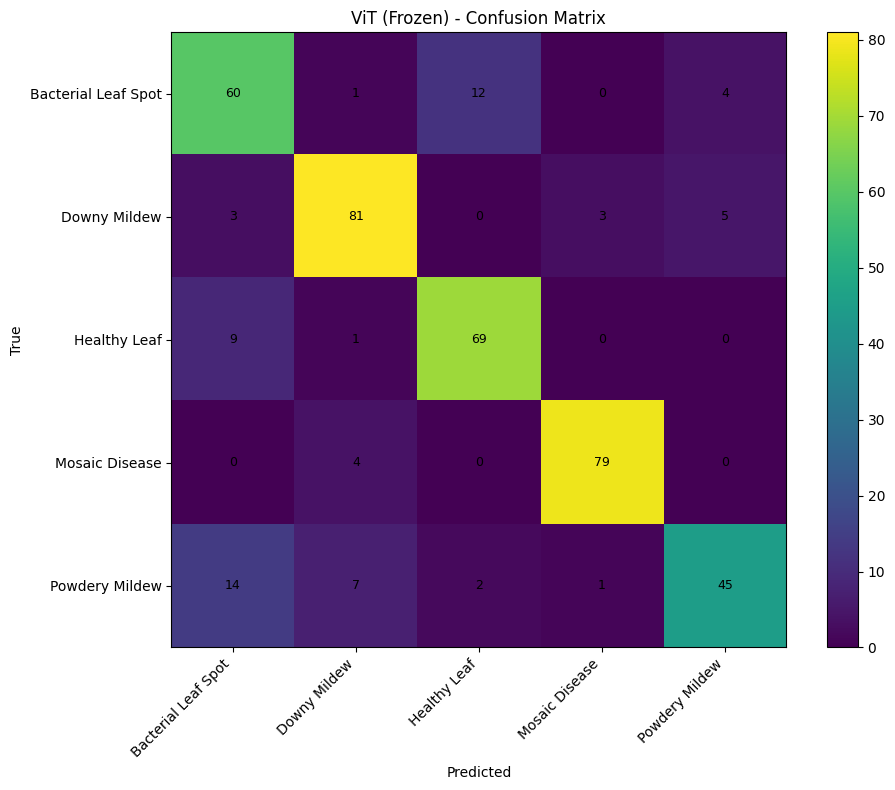

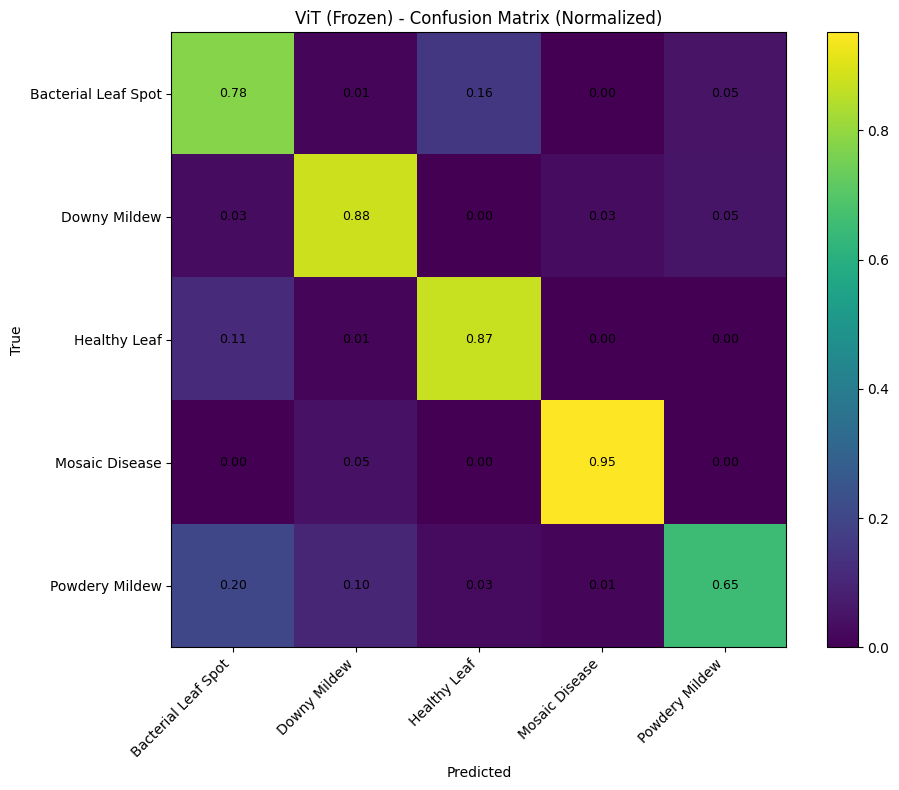


Evaluating: ViT (Partial)
Classification Report
------------------------------------------------------------------------
Class                            Prec      Rec       F1    Support
------------------------------------------------------------------------
Bacterial Leaf Spot             0.696    0.714    0.705         77
Downy Mildew                    0.886    0.848    0.867         92
Healthy Leaf                    0.809    0.911    0.857         79
Mosaic Disease                  0.879    0.964    0.920         83
Powdery Mildew                  0.830    0.638    0.721         69
------------------------------------------------------------------------
Accuracy                        0.822
Macro avg                       0.820    0.815    0.814        400
Weighted avg                    0.823    0.822    0.820        400
------------------------------------------------------------------------


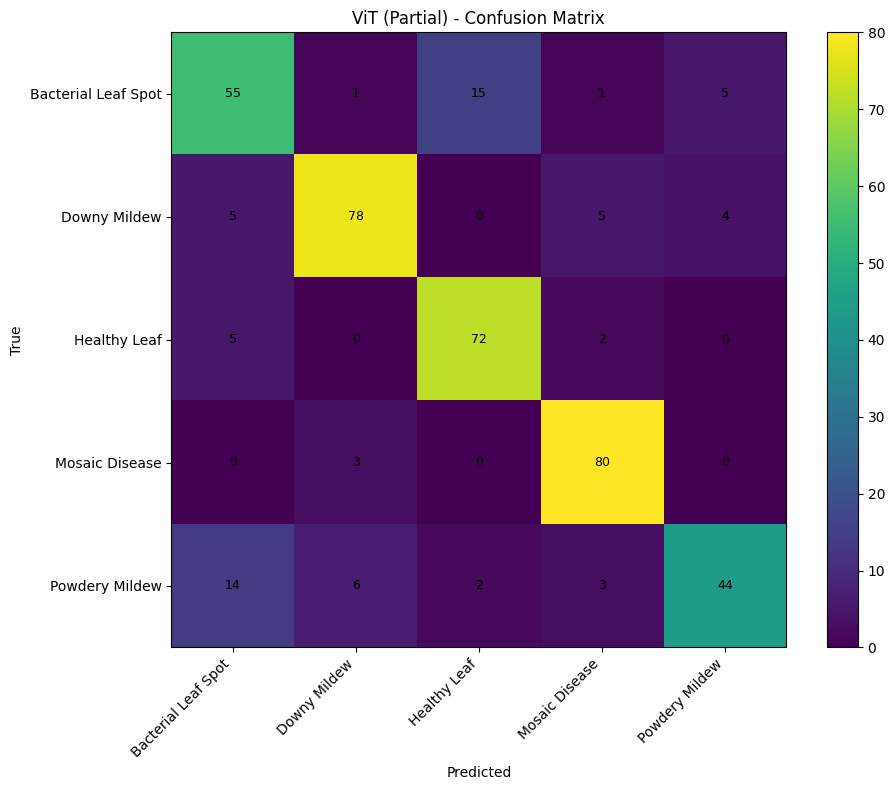

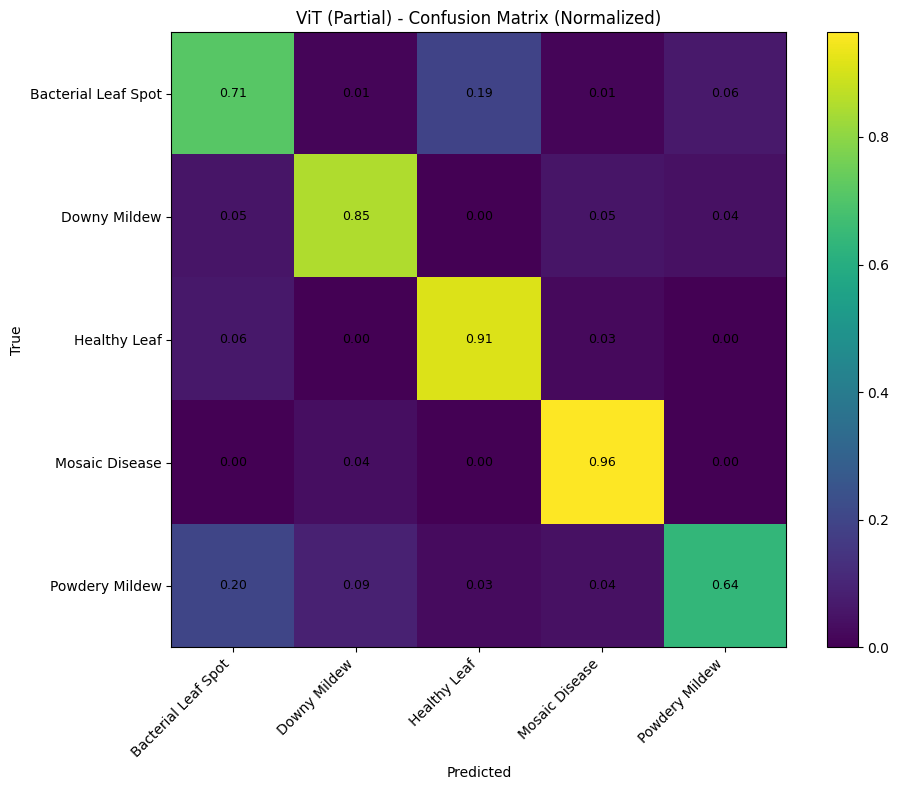


Evaluating: ConViT (Frozen)
Classification Report
------------------------------------------------------------------------
Class                            Prec      Rec       F1    Support
------------------------------------------------------------------------
Bacterial Leaf Spot             0.628    0.636    0.632         77
Downy Mildew                    0.852    0.750    0.798         92
Healthy Leaf                    0.782    0.861    0.819         79
Mosaic Disease                  0.886    0.940    0.912         83
Powdery Mildew                  0.712    0.681    0.696         69
------------------------------------------------------------------------
Accuracy                        0.777
Macro avg                       0.772    0.774    0.772        400
Weighted avg                    0.778    0.777    0.776        400
------------------------------------------------------------------------


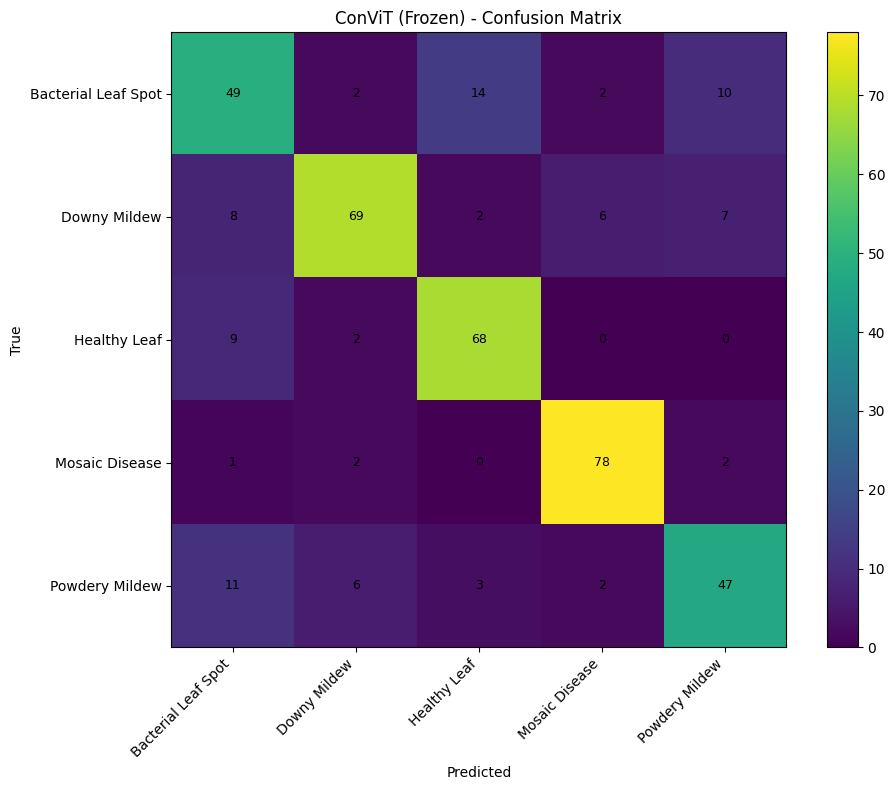

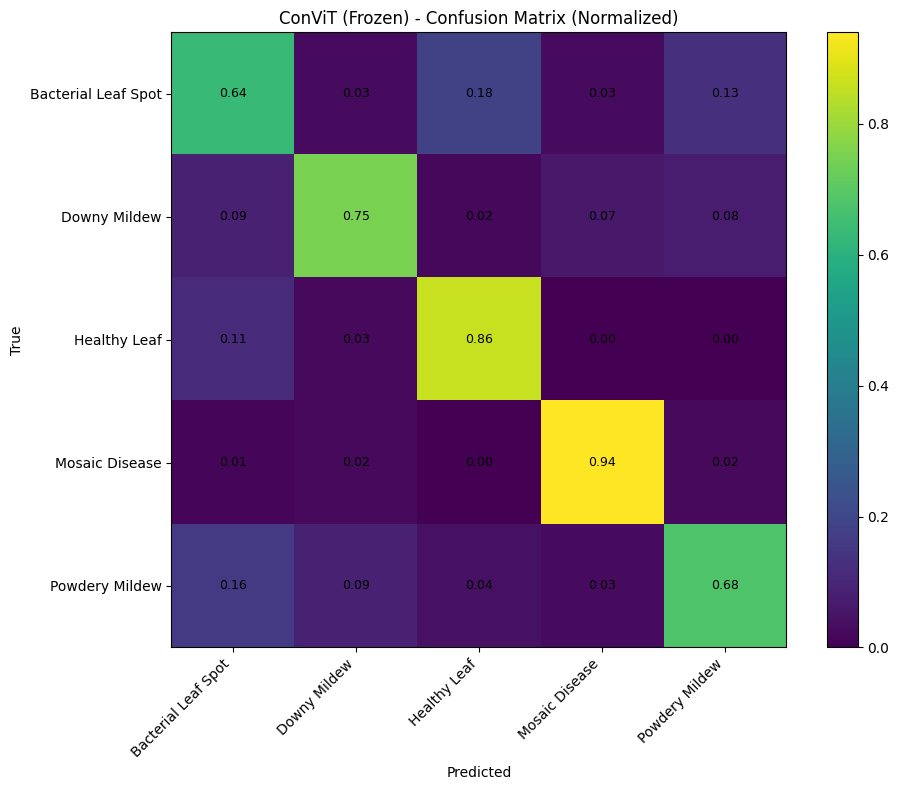


Evaluating: ConViT (Partial)
Classification Report
------------------------------------------------------------------------
Class                            Prec      Rec       F1    Support
------------------------------------------------------------------------
Bacterial Leaf Spot             0.617    0.961    0.751         77
Downy Mildew                    0.871    0.957    0.912         92
Healthy Leaf                    0.960    0.608    0.744         79
Mosaic Disease                  1.000    0.904    0.949         83
Powdery Mildew                  0.870    0.681    0.764         69
------------------------------------------------------------------------
Accuracy                        0.830
Macro avg                       0.864    0.822    0.824        400
Weighted avg                    0.866    0.830    0.830        400
------------------------------------------------------------------------


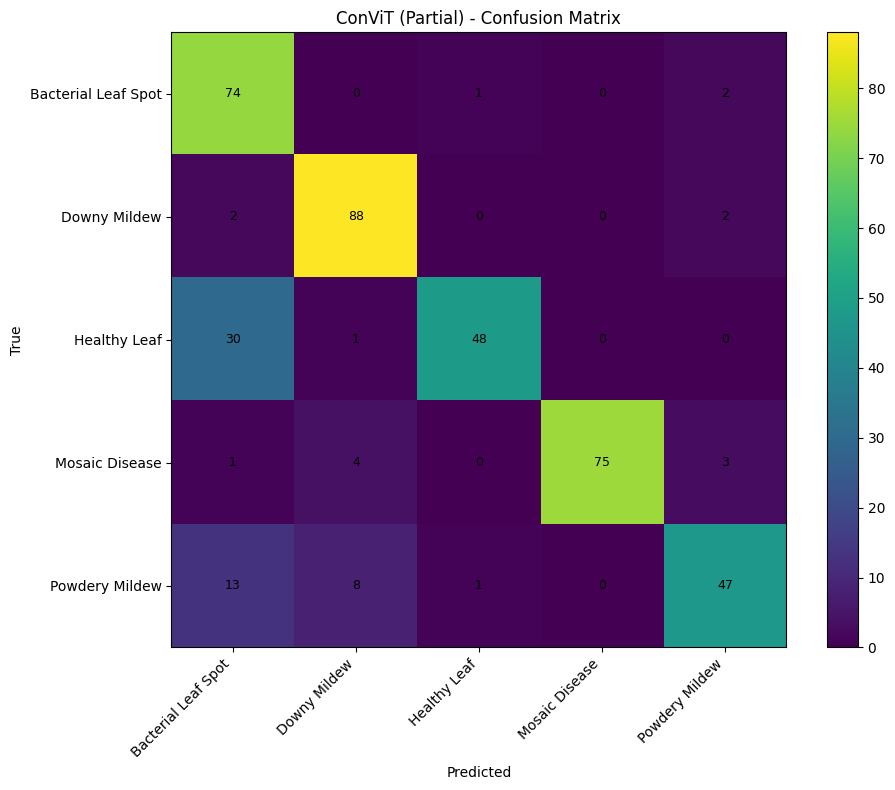

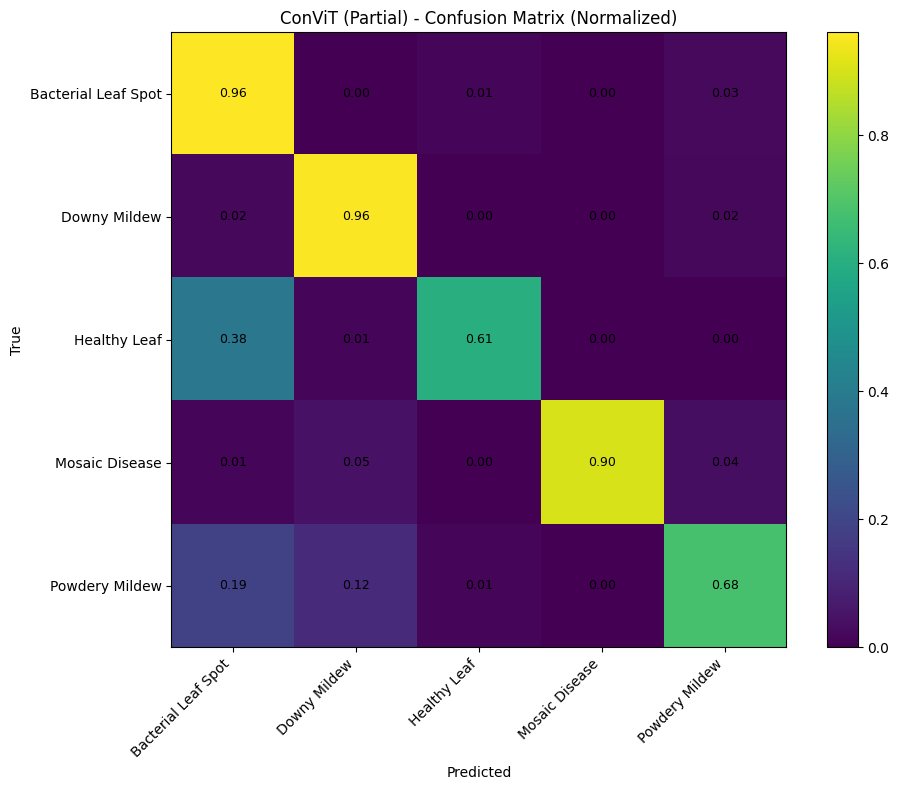


Evaluating: Swin (Frozen)
Classification Report
------------------------------------------------------------------------
Class                            Prec      Rec       F1    Support
------------------------------------------------------------------------
Bacterial Leaf Spot             0.785    0.662    0.718         77
Downy Mildew                    0.853    0.946    0.897         92
Healthy Leaf                    0.813    0.937    0.871         79
Mosaic Disease                  0.951    0.940    0.945         83
Powdery Mildew                  0.783    0.681    0.729         69
------------------------------------------------------------------------
Accuracy                        0.842
Macro avg                       0.837    0.833    0.832        400
Weighted avg                    0.840    0.842    0.838        400
------------------------------------------------------------------------


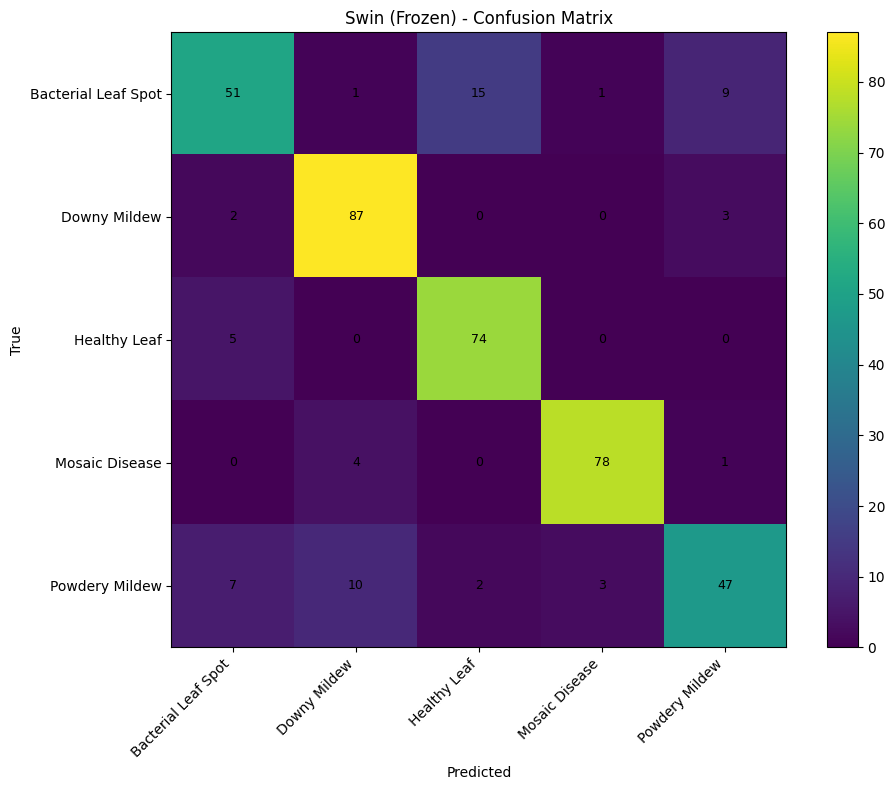

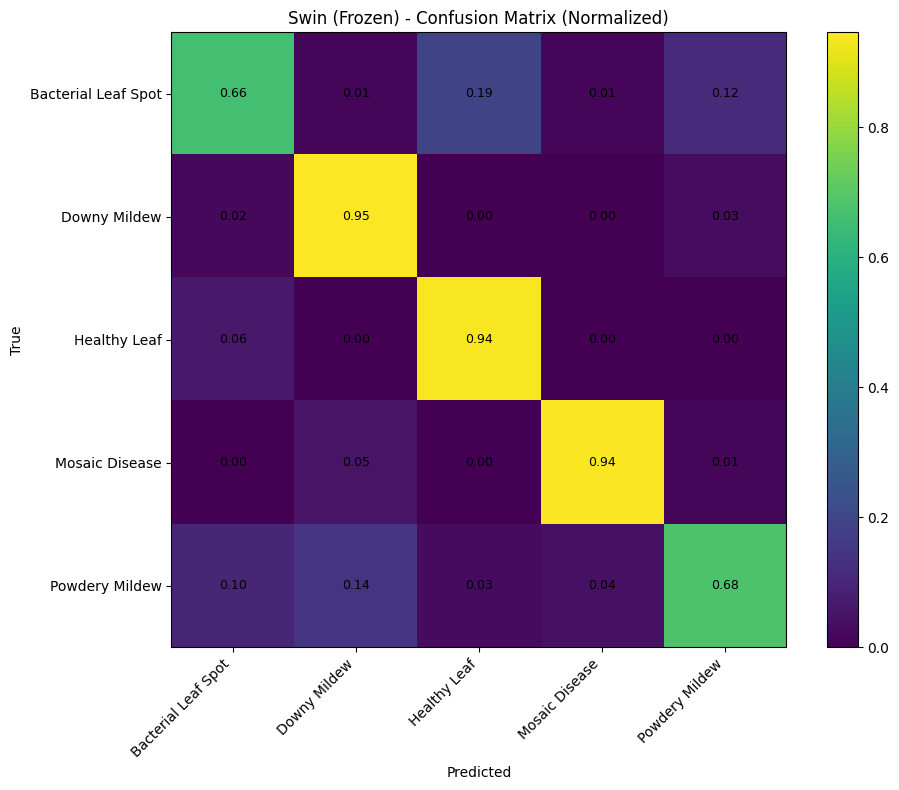


Evaluating: Swin (Partial)
Classification Report
------------------------------------------------------------------------
Class                            Prec      Rec       F1    Support
------------------------------------------------------------------------
Bacterial Leaf Spot             0.825    0.610    0.701         77
Downy Mildew                    0.821    0.946    0.879         92
Healthy Leaf                    0.786    0.975    0.870         79
Mosaic Disease                  0.950    0.916    0.933         83
Powdery Mildew                  0.814    0.696    0.750         69
------------------------------------------------------------------------
Accuracy                        0.837
Macro avg                       0.839    0.828    0.827        400
Weighted avg                    0.840    0.837    0.832        400
------------------------------------------------------------------------


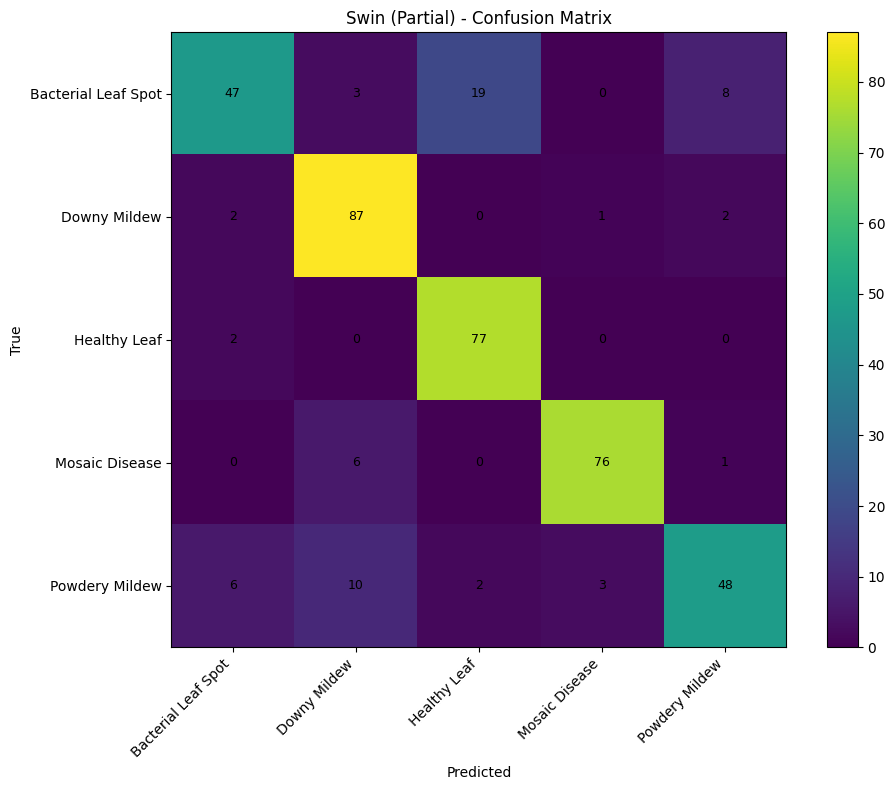

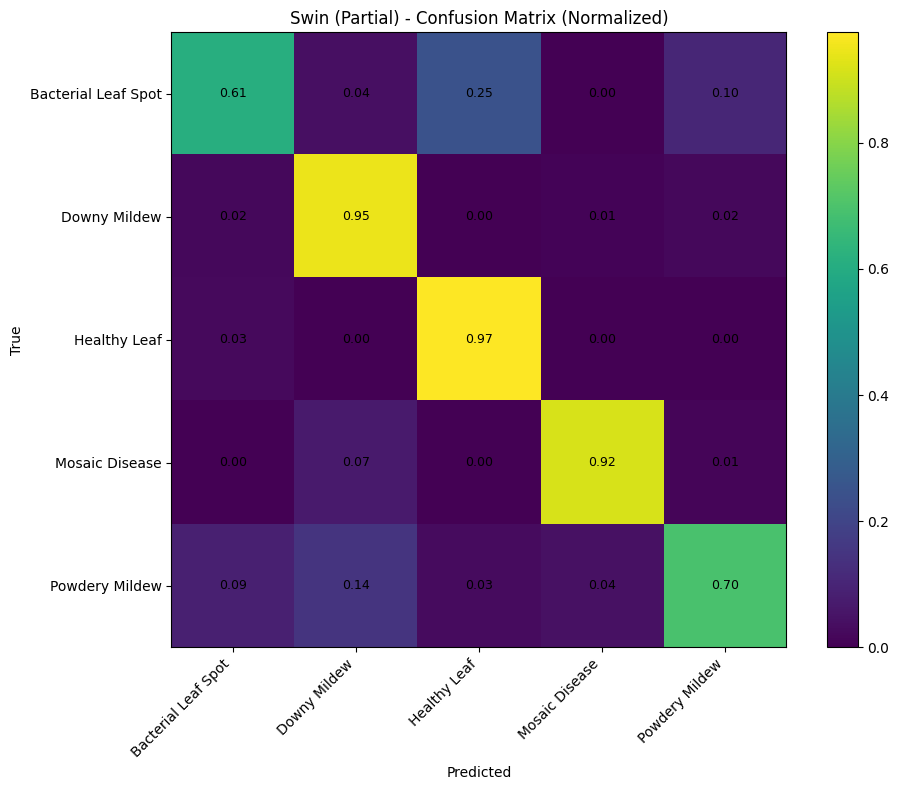

In [12]:
# ---------------------------------------------------------
# Run evaluation for all models
# ---------------------------------------------------------
evaluation_results = {}

for display_name, key in EVAL_MODELS.items():
    model = trained.get(key, None)

    if model is None:
        print(f"Skipping {display_name}: model not available")
        continue

    metrics, cm = evaluate_model(
        model=model,
        model_name=display_name,
        val_loader=val_loader,
        class_names=class_names,
        device=DEVICE,
    )

    evaluation_results[display_name] = {
        "metrics": metrics,
        "confusion_matrix": cm
    }


In [13]:
# ---------------------------------------------------------
# Summary table (Accuracy, Macro-F1, Weighted-F1)
# ---------------------------------------------------------
print("\nModel Comparison Summary")
print("-" * 72)
print(f"{'Model':28s} {'Acc':>8s} {'MacroF1':>10s} {'WeightedF1':>12s}")
print("-" * 72)

for name, res in evaluation_results.items():
    m = res["metrics"]
    acc = m["accuracy"]
    macro_f1 = m["macro"][2]
    weighted_f1 = m["weighted"][2]
    print(f"{name[:28]:28s} {acc:8.3f} {macro_f1:10.3f} {weighted_f1:12.3f}")

print("-" * 72)



Model Comparison Summary
------------------------------------------------------------------------
Model                             Acc    MacroF1   WeightedF1
------------------------------------------------------------------------
ViT (Frozen)                    0.835      0.829        0.834
ViT (Partial)                   0.822      0.814        0.820
ConViT (Frozen)                 0.777      0.772        0.776
ConViT (Partial)                0.830      0.824        0.830
Swin (Frozen)                   0.842      0.832        0.838
Swin (Partial)                  0.837      0.827        0.832
------------------------------------------------------------------------


# Explanation toolkit


## 🔍 Model Explainability Toolkit for Vision Transformers

### Interpretable Analysis of ViT, ConViT, and Swin Transformer Models

This section implements a unified **explainable AI (XAI) toolkit** for analyzing the decision-making behavior of modern **transformer-based vision models** trained via transfer learning. The toolkit supports three representative architectures with architecture-appropriate explanation methods:

* **Vision Transformer (ViT)**
  Uses **attention rollout** to propagate multi-layer self-attention and estimate **CLS → patch relevance**, highlighting image regions that contribute most to the final prediction.

* **Convolutional Vision Transformer (ConViT)**
  Applies the same **attention rollout mechanism**, enabling direct comparison with ViT while accounting for convolutional inductive biases embedded in the transformer blocks.

* **Swin Transformer**
  Employs **gradient-based feature attribution** on hierarchical windowed representations, computing importance scores as the absolute product of feature activations and their gradients with respect to the predicted class.

### Key Capabilities

* Architecture-aware explainability (no one-size-fits-all heuristics)
* Robust handling of token and spatial resolution differences
* Visual outputs including **heatmaps**, **overlays**, and **input comparisons**
* Fully compatible with `timm` pretrained and fine-tuned models
* Designed for **Kaggle notebooks, research experiments, and classroom labs**

This toolkit enables **qualitative model inspection**, **failure analysis**, and **comparative interpretability studies** across transformer families, providing insights into how different architectural choices influence visual reasoning.




### ATTENTION ROLLOUT TOOLKIT (ViT + ConViT) - Normalized Input Image

In [14]:
# -----------------------------
# FIX: ensure pil_img exists
# -----------------------------
from PIL import Image

# 1) If you already have pil_img, do nothing
if "pil_img" not in globals() or pil_img is None:
    pil_img = None

    # 2) Try: val_base dataset (common in your notebook)
    if pil_img is None and "val_base" in globals():
        try:
            sample = val_base[0]                # (PIL, y) or (tensor, y)
            pil_img = sample[0]
        except Exception:
            pass

    # 3) Try: val_loader dataset
    if pil_img is None and "val_loader" in globals():
        try:
            ds = val_loader.dataset
            sample = ds[0]
            pil_img = sample[0]
        except Exception:
            pass

    # 4) If dataset returns tensor, convert tensor->PIL (best-effort)
    if pil_img is not None and torch.is_tensor(pil_img):
        # tensor expected CHW in [0,1] or normalized; we just make it viewable
        t = pil_img.detach().cpu()
        if t.dim() == 3 and t.shape[0] in (1,3):
            if t.shape[0] == 1:
                t = t.repeat(3,1,1)
            t = t.permute(1,2,0).numpy()
            t = np.clip(t, 0, 1)
            pil_img = Image.fromarray((t*255).astype(np.uint8))

    # 5) Last resort: load from path (set your own path here)
    # IMG_PATH = "/kaggle/input/your-dataset/your_image.jpg"
    # if pil_img is None:
    #     pil_img = Image.open(IMG_PATH).convert("RGB")

    if pil_img is None:
        raise NameError(
            "pil_img is not defined and could not be auto-created. "
            "Define pil_img from your dataset (e.g., pil_img, y = val_base[0]) "
            "or set IMG_PATH and load it."
        )


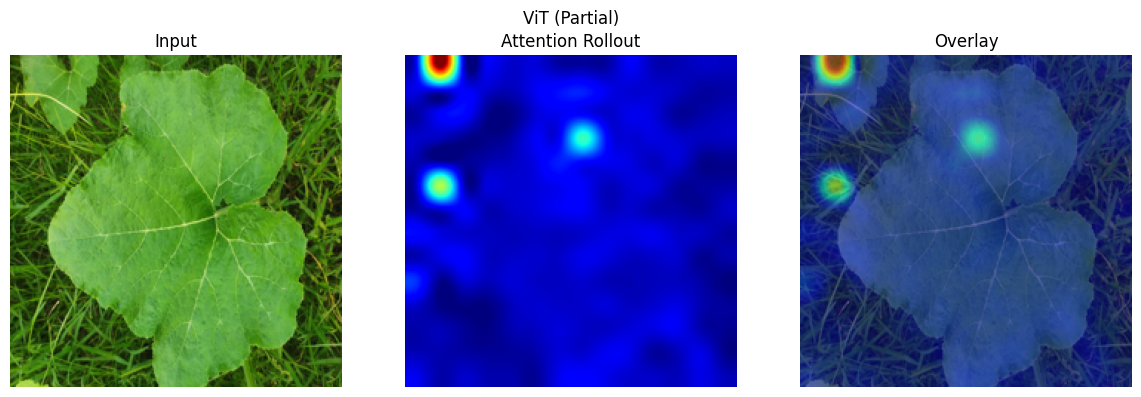

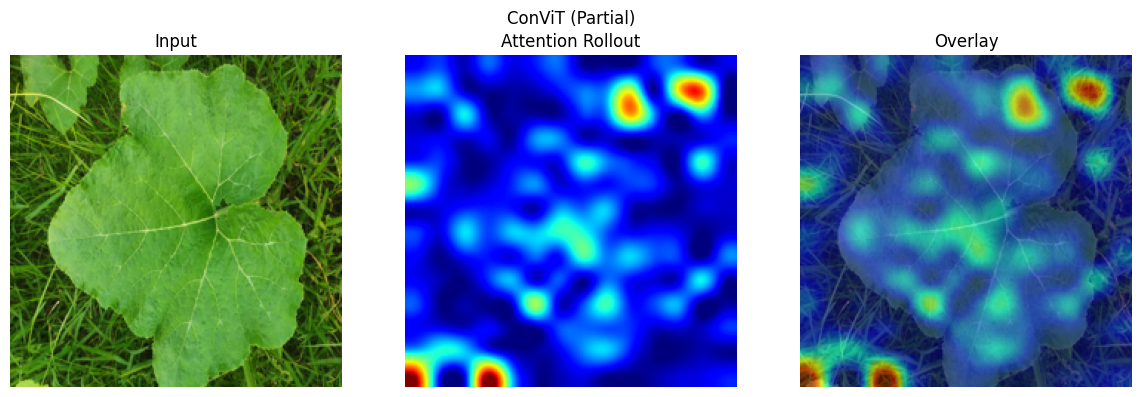

In [15]:
# =========================================================
# ATTENTION ROLLOUT TOOLKIT (ViT + ConViT) 
# =========================================================

import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
@dataclass
class AttentionVizConfig:
    patch_start_idx: int = 1      # CLS token index
    img_size: int = 224
    alpha: float = 0.5
    max_layers: int = 24

# ---------------------------------------------------------
# Model capability registry (CRITICAL)
# ---------------------------------------------------------
MODEL_ATTENTION_SUPPORT = {
    "vit": {
        "supports_rollout": True,
        "patch_start_idx": 1,
        "note": "Standard ViT attention rollout"
    },
    "convit": {
        "supports_rollout": True,
        "patch_start_idx": 1,
        "note": "ConViT attention rollout (ViT-compatible)"
    },
    "swin": {
        "supports_rollout": False,
        "note": "Swin uses windowed attention – rollout not valid"
    },
    "mobilevit": {
        "supports_rollout": False,
        "note": "MobileViT is CNN–Transformer hybrid – rollout not valid"
    }
}

# ---------------------------------------------------------
# Utilities
# ---------------------------------------------------------
def pil_to_uint8_rgb(pil_img, size=224):
    arr = np.array(pil_img.resize((size, size)))
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    return arr.astype(np.uint8)

def apply_colormap_on_01(heat_01):
    heat_u8 = np.uint8(np.clip(heat_01, 0, 1) * 255)
    heat_bgr = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    return cv2.cvtColor(heat_bgr, cv2.COLOR_BGR2RGB)

def overlay_rgb(base, heat, alpha=0.5):
    out = base.astype(np.float32) * (1 - alpha) + heat.astype(np.float32) * alpha
    return np.clip(out, 0, 255).astype(np.uint8)

# ---------------------------------------------------------
# Attention patching (timm ViT / ConViT safe)
# ---------------------------------------------------------
def _can_patch_attn(attn: nn.Module) -> bool:
    needed = ["qkv", "num_heads", "scale", "attn_drop", "proj", "proj_drop"]
    return all(hasattr(attn, k) for k in needed)

def _make_attn_forward_with_capture(attn: nn.Module, store: list):
    def forward(x, attn_mask=None, **kwargs):
        B, N, C = x.shape
        qkv = attn.qkv(x).reshape(
            B, N, 3, attn.num_heads, C // attn.num_heads
        ).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        A = (q @ k.transpose(-2, -1)) * attn.scale
        A = A.softmax(dim=-1)
        A = attn.attn_drop(A)

        store.append(A.detach())

        x = (A @ v).transpose(1, 2).reshape(B, N, C)
        x = attn.proj(x)
        x = attn.proj_drop(x)
        return x
    return forward

@torch.no_grad()
def capture_attention_stack(model, x, max_layers):
    model.eval()
    if not hasattr(model, "blocks"):
        return []

    attn_store, originals, patched = [], [], []

    for blk in model.blocks:
        if hasattr(blk, "attn") and _can_patch_attn(blk.attn):
            originals.append(blk.attn.forward)
            blk.attn.forward = _make_attn_forward_with_capture(blk.attn, attn_store)
            patched.append(blk.attn)

    _ = model(x)

    for attn, orig in zip(patched, originals):
        attn.forward = orig

    return attn_store[-max_layers:]

# ---------------------------------------------------------
# Attention Rollout math
# ---------------------------------------------------------
def attention_rollout(attn_list):
    A = [a.mean(dim=1) for a in attn_list]  # (B, T, T)
    B, T, _ = A[0].shape
    I = torch.eye(T).unsqueeze(0).to(A[0].device)

    R = I.clone()
    for a in A:
        a = a + I
        a = a / (a.sum(dim=-1, keepdim=True) + 1e-12)
        R = torch.bmm(a, R)
    return R

def rollout_to_heatmap(R, img_size, patch_start_idx):
    cls_vec = R[0, 0, patch_start_idx:]
    cls_vec = (cls_vec - cls_vec.min()) / (cls_vec.max() - cls_vec.min() + 1e-6)

    n = cls_vec.numel()
    g = int(np.sqrt(n))
    grid = cls_vec.view(g, g).cpu().numpy()

    heat = cv2.resize(grid, (img_size, img_size), interpolation=cv2.INTER_CUBIC)
    return np.clip(heat, 0, 1)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def denorm_tensor_to_uint8_rgb(x_chw: torch.Tensor):
    """
    x_chw: (3,H,W) tensor AFTER Normalize(mean,std)
    returns uint8 RGB image (H,W,3)
    """
    mean = torch.tensor(IMAGENET_MEAN, device=x_chw.device).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD,  device=x_chw.device).view(3,1,1)
    x = x_chw * std + mean
    x = x.clamp(0,1)
    x = (x.permute(1,2,0) * 255.0).byte().cpu().numpy()
    return x


# ---------------------------------------------------------
# Visualization core
# ---------------------------------------------------------
@torch.no_grad()
def visualize_attention_rollout_patched(
    model, pil_img, val_tfms, device,
    img_size, patch_start_idx, alpha, title
):
    x = val_tfms(pil_img).unsqueeze(0).to(device)
    img = pil_to_uint8_rgb(pil_img, img_size)
    img

    attn_list = capture_attention_stack(model, x, max_layers=24)
    if len(attn_list) == 0:
        print("[WARN] No attention captured")
        return

    R = attention_rollout(attn_list)
    heat = rollout_to_heatmap(R, img_size, patch_start_idx)

    heat_rgb = apply_colormap_on_01(heat)
    over = overlay_rgb(img, heat_rgb, alpha)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img); plt.axis("off"); plt.title("Input")
    plt.subplot(1,3,2); plt.imshow(heat, cmap="jet"); plt.axis("off"); plt.title("Attention Rollout")
    plt.subplot(1,3,3); plt.imshow(over); plt.axis("off"); plt.title("Overlay")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



# ---------------------------------------------------------
# Dispatcher (PUBLIC API)
# ---------------------------------------------------------
@torch.no_grad()
def explain_with_attention(
    model,
    model_type,
    pil_img,
    val_tfms,
    device,
    config: AttentionVizConfig,
    title=""
):
    assert model_type in MODEL_ATTENTION_SUPPORT
    cfg = MODEL_ATTENTION_SUPPORT[model_type]

    if not cfg["supports_rollout"]:
        print(f"[INFO] Attention rollout not supported for {model_type.upper()}")
        print(f"       Reason: {cfg['note']}")
        return

    visualize_attention_rollout_patched(
        model=model,
        pil_img=pil_img,
        val_tfms=val_tfms,
        device=device,
        img_size=config.img_size,
        patch_start_idx=cfg["patch_start_idx"],
        alpha=config.alpha,
        title=title
    )

# =========================================================
# USAGE EXAMPLES
# =========================================================

cfg = AttentionVizConfig(alpha=0.55)

# ViT
explain_with_attention(
    model=trained['vit_partial'],
    model_type="vit",
    pil_img=pil_img,
    val_tfms=val_tfms,
    device=DEVICE,
    config=cfg,
    title="ViT (Partial)"
)

# ConViT
explain_with_attention(
    model=trained['convit_partial'],
    model_type="convit",
    pil_img=pil_img,
    val_tfms=val_tfms,
    device=DEVICE,
    config=cfg,
    title="ConViT (Partial)"
)


## Swin Transformer XAI (Feature Attribution via Gradients)

In [16]:
# ===========================
# Swin Transformer XAI (Feature Attribution via Gradients)
# Full, robust end-to-end code
# - Works with timm Swin (trained models)
# - Uses gradient-based feature attribution (NOT Grad-CAM, NOT attention rollout)
# - Handles different activation shapes safely
# - Integrates with your trained + EVAL_MODELS registry
# ===========================
# -----------------------------
# Utilities: image + heatmap
# -----------------------------
def pil_to_uint8_rgb(pil_img, size=224):
    arr = np.array(pil_img.resize((size, size)))
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    return arr.astype(np.uint8)

def apply_colormap_on_01(heat_01: np.ndarray):
    heat_u8 = np.uint8(np.clip(heat_01, 0, 1) * 255)
    heat_bgr = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    return cv2.cvtColor(heat_bgr, cv2.COLOR_BGR2RGB)

def overlay_rgb(base_rgb_u8: np.ndarray, heat_rgb_u8: np.ndarray, alpha=0.55):
    out = base_rgb_u8.astype(np.float32) * (1 - alpha) + heat_rgb_u8.astype(np.float32) * alpha
    return np.clip(out, 0, 255).astype(np.uint8)

# -----------------------------
# Core: find a good Swin spatial hook
# -----------------------------
def _get_module_by_dotted_name(root: torch.nn.Module, dotted: str):
    cur = root
    for part in dotted.split("."):
        if part.isdigit():
            cur = cur[int(part)]
        else:
            cur = getattr(cur, part)
    return cur

def _swin_candidate_hook_modules(model: torch.nn.Module):
    """
    Returns a list of candidate modules that tend to produce spatial feature tensors in timm Swin.
    We try "model.layers[-1].blocks[-1].norm2" etc. If missing, we fallback.
    """
    candidates = []

    # Common timm Swin structure:
    # model.layers: list of stages
    # each stage has .blocks: list of SwinTransformerBlock
    # block has norm1, attn, norm2, mlp
    if hasattr(model, "layers"):
        try:
            last_stage = model.layers[-1]
            if hasattr(last_stage, "blocks") and len(last_stage.blocks) > 0:
                last_block = last_stage.blocks[-1]
                # norm2 output is usually (B, L, C) or (B, H, W, C) depending on internal layout
                if hasattr(last_block, "norm2"):
                    candidates.append(last_block.norm2)
                # mlp output can also be spatial
                if hasattr(last_block, "mlp"):
                    candidates.append(last_block.mlp)
        except Exception:
            pass

    # Fallback: model.norm exists in many timm Swin versions
    if hasattr(model, "norm"):
        candidates.append(model.norm)

    # Fallback: any LayerNorm in last layers if structure differs
    for name, m in model.named_modules():
        if name.endswith("norm2") or name.endswith("norm"):
            candidates.append(m)

    # Deduplicate while preserving order
    seen = set()
    uniq = []
    for m in candidates:
        if id(m) not in seen:
            uniq.append(m)
            seen.add(id(m))
    return uniq

# -----------------------------
# XAI: Gradient-based feature attribution
# -----------------------------
@torch.enable_grad()
def swin_feature_attribution(
    model: torch.nn.Module,
    x: torch.Tensor,
    class_idx: int,
    hook_module: torch.nn.Module,
):
    """
    Returns:
      cam_01: numpy (H,W) normalized to [0,1]
      debug: dict with shapes + which branch was used
    """
    model.eval()
    model.zero_grad(set_to_none=True)

    activations = {"A": None}
    gradients   = {"G": None}

    def fwd_hook(_, __, out):
        # Save activation (keep graph for gradients)
        activations["A"] = out
        # Ensure we capture gradients for out
        def _save_grad(g):
            gradients["G"] = g
        out.register_hook(_save_grad)

    h = hook_module.register_forward_hook(fwd_hook)

    logits = model(x)
    score = logits[0, class_idx]
    score.backward()

    h.remove()

    A = activations["A"]
    G = gradients["G"]
    if A is None or G is None:
        raise RuntimeError(
            "Attribution failed: activations or gradients are None.\n"
            "Try a different hook_module (later stage norm2/mlp/norm)."
        )

    debug = {"A_shape": tuple(A.shape), "G_shape": tuple(G.shape), "branch": None}

    # Remove batch dimension
    # Handle typical Swin outputs:
    # 1) (B, L, C)
    # 2) (B, H, W, C)
    # 3) (B, C, H, W)
    if A.dim() == 3:  # (B, L, C)
        A0 = A[0]  # (L, C)
        G0 = G[0]  # (L, C)
        L, C = A0.shape

        # Attempt to infer square grid
        s = int(np.sqrt(L))
        if s * s != L:
            raise RuntimeError(
                f"Attribution layer produced tokens L={L} that are not a perfect square.\n"
                "Pick a later spatial layer (e.g., last_stage.blocks[-1].norm2) or a different candidate."
            )

        token_scores = (A0 * G0).abs().sum(dim=1)  # (L,)
        token_scores -= token_scores.min()
        token_scores /= (token_scores.max() + 1e-6)

        cam = token_scores.reshape(s, s).detach().cpu().numpy()
        debug["branch"] = "(B,L,C)->square"

    elif A.dim() == 4 and A.shape[-1] == G.shape[-1]:
        # likely (B, H, W, C)
        A0 = A[0]  # (H,W,C)
        G0 = G[0]  # (H,W,C)

        # channel-wise score (sum over C)
        cam_t = (A0 * G0).abs().sum(dim=-1)  # (H,W)
        cam_t -= cam_t.min()
        cam_t /= (cam_t.max() + 1e-6)
        cam = cam_t.detach().cpu().numpy()
        debug["branch"] = "(B,H,W,C)"

    elif A.dim() == 4 and A.shape[1] == G.shape[1]:
        # likely (B, C, H, W)
        A0 = A[0]  # (C,H,W)
        G0 = G[0]  # (C,H,W)

        # Gradient-based channel weights
        w = G0.mean(dim=(1, 2), keepdim=True)  # (C,1,1)
        cam_t = (w * A0).sum(dim=0)            # (H,W)
        cam_t = torch.relu(cam_t)
        cam_t -= cam_t.min()
        cam_t /= (cam_t.max() + 1e-6)
        cam = cam_t.detach().cpu().numpy()
        debug["branch"] = "(B,C,H,W)"

    else:
        raise RuntimeError(
            f"Unsupported activation layout for Swin attribution: A={tuple(A.shape)}, G={tuple(G.shape)}"
        )

    cam = np.clip(cam, 0, 1)
    return cam, logits.detach(), debug

# -----------------------------
# High-level: visualize from registry
# -----------------------------
@torch.enable_grad()
def visualize_swin_feature_attribution_from_registry(
    trained: dict,
    EVAL_MODELS: dict,
    display_name: str,
    pil_img,
    val_tfms,
    class_names,
    device,
    img_size=224,
    overlay_alpha=0.55,
    title_prefix="XAI | ",
    prefer_topk_candidates=6,
):
    """
    Attempts multiple safe hook points for Swin until attribution works.
    Shows: input, heatmap, overlay + predicted class probabilities.
    """
    assert display_name in EVAL_MODELS, f"display_name not in EVAL_MODELS: {display_name}"
    model_key = EVAL_MODELS[display_name]
    assert model_key in trained, f"Model key not in trained: {model_key}"

    model = trained[model_key].to(device).eval()

    x = val_tfms(pil_img).unsqueeze(0).to(device)
    x.requires_grad_(True)

    # prediction (no grad disabled because we need backward)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0]
    pred_idx = int(probs.argmax())
    pred_name = class_names[pred_idx]
    print(f"[INFO] Predicted class index: {pred_idx} ({pred_name})")

    # Prepare image
    np_img = pil_to_uint8_rgb(pil_img, size=img_size)

    # Try multiple hook points
    candidates = _swin_candidate_hook_modules(model)
    candidates = candidates[:max(1, prefer_topk_candidates)]

    last_err = None
    best_debug = None
    cam = None
    for i, m in enumerate(candidates):
        try:
            cam, logits2, debug = swin_feature_attribution(
                model=model,
                x=x,
                class_idx=pred_idx,
                hook_module=m,
            )
            best_debug = debug
            break
        except Exception as e:
            last_err = e

    if cam is None:
        raise RuntimeError(
            "All Swin attribution hook candidates failed.\n"
            f"Last error: {type(last_err).__name__}: {last_err}\n"
            "Tip: Print model, inspect model.layers[-1].blocks[-1] and choose a later norm2/mlp module."
        )

    # Resize cam to image size
    cam_rs = cv2.resize(cam, (img_size, img_size), interpolation=cv2.INTER_CUBIC)
    cam_rs = np.clip(cam_rs, 0, 1)

    heat_rgb = apply_colormap_on_01(cam_rs)
    overlay = overlay_rgb(np_img, heat_rgb, alpha=overlay_alpha)

    # Show top-5 probs
    topk = min(5, len(class_names))
    top_vals, top_idx = torch.topk(probs, k=topk)
    top_vals = top_vals.detach().cpu().numpy()
    top_idx = top_idx.detach().cpu().numpy()

    # Plot
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(np_img)
    plt.axis("off")
    plt.title("Input")

    plt.subplot(1, 4, 2)
    plt.imshow(cam_rs, cmap="jet")
    plt.axis("off")
    plt.title("Feature Attribution")

    plt.subplot(1, 4, 3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Overlay")

    plt.subplot(1, 4, 4)
    y = np.arange(topk)
    plt.barh(y, top_vals)
    plt.yticks(y, [class_names[i] for i in top_idx])
    plt.gca().invert_yaxis()
    plt.title("Top-k probs")
    plt.xlabel("Probability")
    plt.tight_layout()

    plt.suptitle(f"{title_prefix}{display_name} | Pred: {pred_name}")
    plt.show()

    print("[DEBUG] Attribution hook output:", best_debug)

[INFO] Predicted class index: 2 (Healthy Leaf)


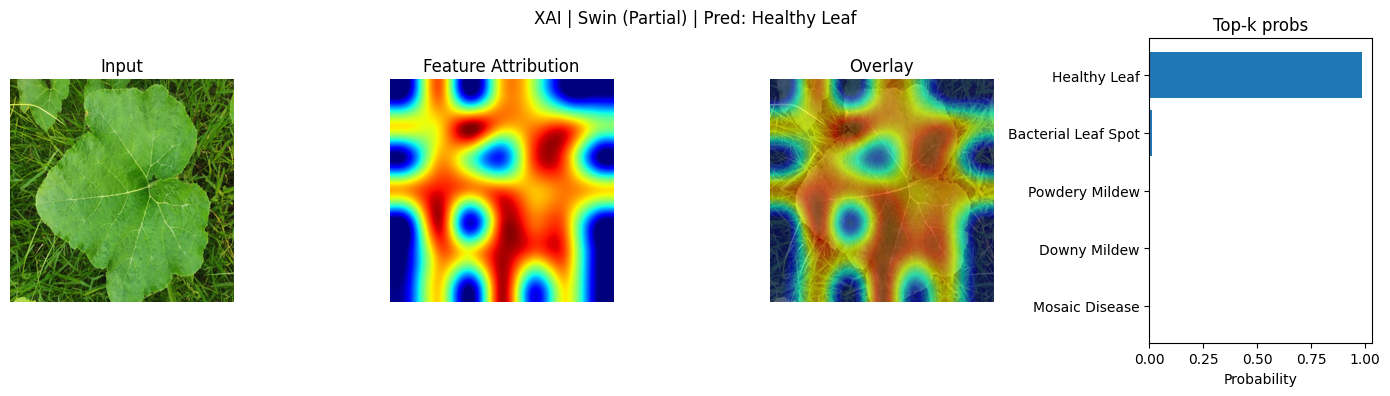

[DEBUG] Attribution hook output: {'A_shape': (1, 49, 1024), 'G_shape': (1, 49, 1024), 'branch': '(B,L,C)->square'}


In [17]:
# -----------------------------
# Example usage (your setup)
# -----------------------------
visualize_swin_feature_attribution_from_registry(
     trained=trained,
     EVAL_MODELS=EVAL_MODELS,
     display_name="Swin (Partial)",
     pil_img=pil_img,
     val_tfms=val_tfms,
     class_names=class_names,
     device=DEVICE,
     img_size=IMG_SIZE,
     overlay_alpha=0.55,
     title_prefix="XAI | ",
)